# EDA Agrupación Raíz 

En este notebook se realizara un analisis exploratorio despues de las agrupaciones y de la limpeza de los datos a ver como se organizan los nuevos generos. En esta agrupación titulada **Raíz** se mantuvieron casi los mismos géneros solo se agruparon las variables estrictamente necesarias. Los grupos quedaron de la siguiene manera: 

|    | Categoría Final | Géneros Originales Incluidos                    | Concepto de Agrupación                                                            |
|----|-----------------|-------------------------------------------------|-----------------------------------------------------------------------------------|
| 1  | mainstream      | Pop, Dance, Rock, Alternative, Indie, R&B, Soul | Música de consumo masivo con alta producción y estructuras comerciales.           |
| 2  | hiphop          | Hip-Hop, Rap                                    | Géneros basados en el beat y el fraseo rítmico.                                   |
| 3  | electronic      | Electronic                                      | Música producida predominantemente con sintetizadores y DAWs.                     |
| 4  | jazz_blues      | Jazz, Blues                                     | Estilos con raíces afroamericanas basados en la improvisación y armonía compleja. |
| 5  | latin           | Reggaeton                                       | Ritmos latinos modernos de alta energía (urbano latino).                          |
| 6  | reggae          | Reggae, Ska                                     | Música de origen jamaicano con énfasis en el "off-beat".                          |
| 7  | clásico         | Classical, Opera                                | Música académica, orquestal y de tradición europea.                               |
| 8  | folk_country    | Folk, Country                                   | Estilos tradicionales basados en la narrativa y la instrumentación acústica.      |
| 9  | soundtrack      | Soundtrack, Movie, Anime                        | Composiciones diseñadas para acompañar medios visuales y narrativos.              |
| 10 | kids            | Children’s Music, Children's Music              | Contenido educativo o recreativo enfocado en público infantil.                    |
| 11 | comedy          | Comedy                                          | Performance vocal o musical enfocada en el humor.                                 |
| 12 | world           | World                                           | Música tradicional o folclórica de diversas regiones del mundo.                   |
| 13 | other           | Cualquier otro no listado                       | Categoría de seguridad para datos atípicos o no identificados.                    |


### Preprocesamiento 


In [1]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import src.features.preprocessing as prep
importlib.reload(prep) 
df, x, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,soundtrack
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,soundtrack
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,soundtrack
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,soundtrack
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,soundtrack


### Distribución de géneros 

Podemos observar que luego de reagrupar lo grupos hay un desbalanceo considerable de la variable Children's Music y el resto de variables que tenemos ahí. Así que antes de hacer los modelos tenemos que balancear los datos 


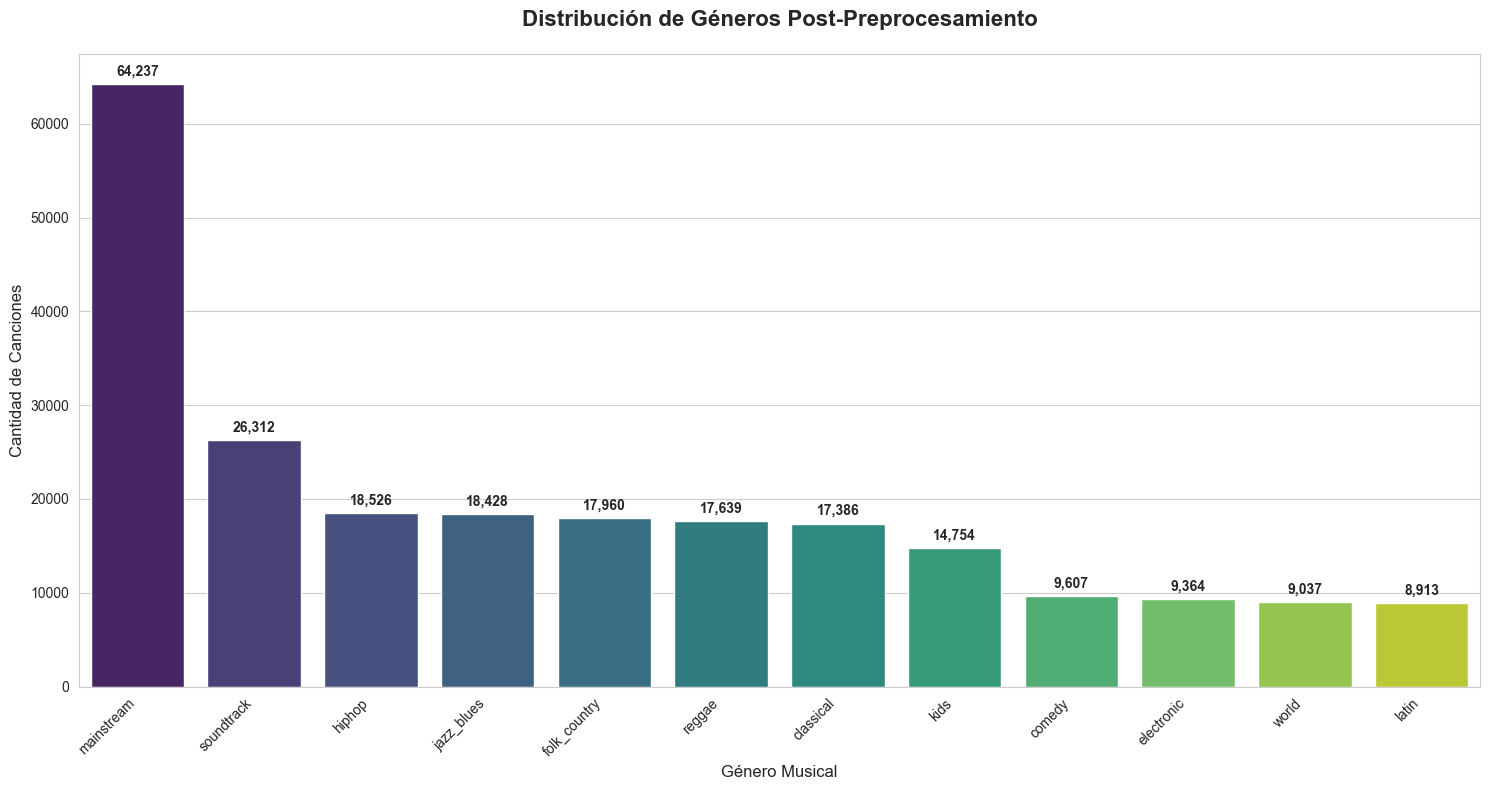

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = df['genre_grouped'].value_counts()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
plt.title('Distribución de Géneros Post-Preprocesamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Como se puede observar en el grafico luego de la agrupación de los diferentes generos musicales hay un desbalanceo grande de Mainstream con respecto a los demas grupos, por lo tanto, antes de aplicar el modelo se deben aplicar tecnicas de desbalanceo para balancear los datos

In [3]:
stats_despues = {
    'Num. Clases': df['genre_grouped'].nunique(),
    'Mínimo muestras': df['genre_grouped'].value_counts().min(),
    'Máximo muestras': df['genre_grouped'].value_counts().max(),
    'Promedio por clase': df['genre_grouped'].value_counts().mean()
}

stats_despues

{'Num. Clases': 12,
 'Mínimo muestras': 8913,
 'Máximo muestras': 64237,
 'Promedio por clase': 19346.916666666668}

Los stats_despues, muestra la cantidad de grupos que se hicieron luego de agrupar los diferentes generos musciales que se encontraban registrados en la base de datos en 12 grupos diferentes, y en base a estos stats una vez mas se prueba el desbalanceo tan masivo que hay entre los grupos, nada mas reflejandolo en el grupo con mayor cantidad de datos y el grupo con menor cantidad de datos
$$
\frac{64237}{8913} \approx 7.2
$$
Como resultado se muestra que el grupo mas grande "Mainstream" tiene poco mas de 7 veces mas datos que el grupo mas pequeño. Adicionalmente a lo anteriormente mencionado en el promedio se muestra que en promedio cada grupo tiene alrededor de 19383 datos cada uno, pero esto se debe a la gran cantidad de datos que tiene "Mainstream" lo que causa que el promedio se vea tan afectado

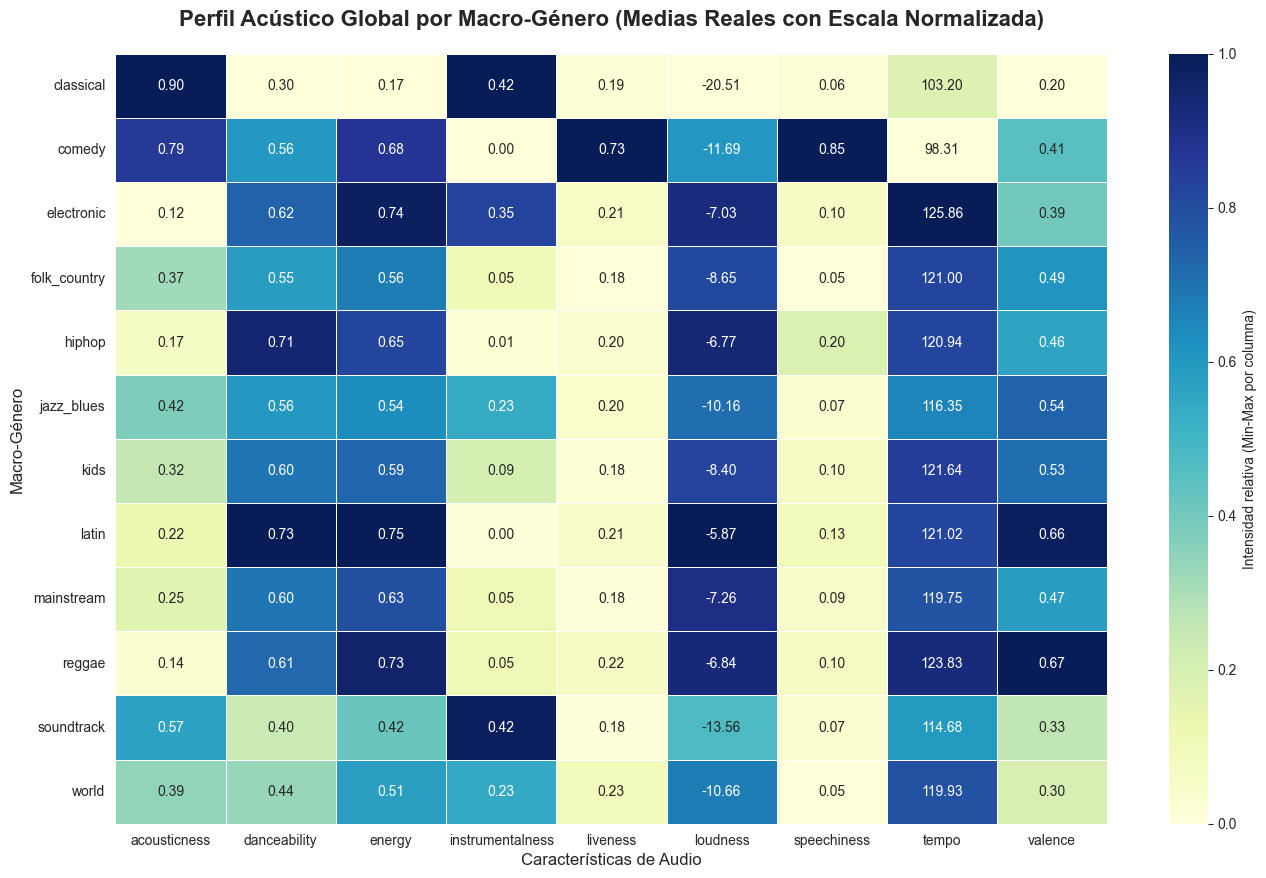

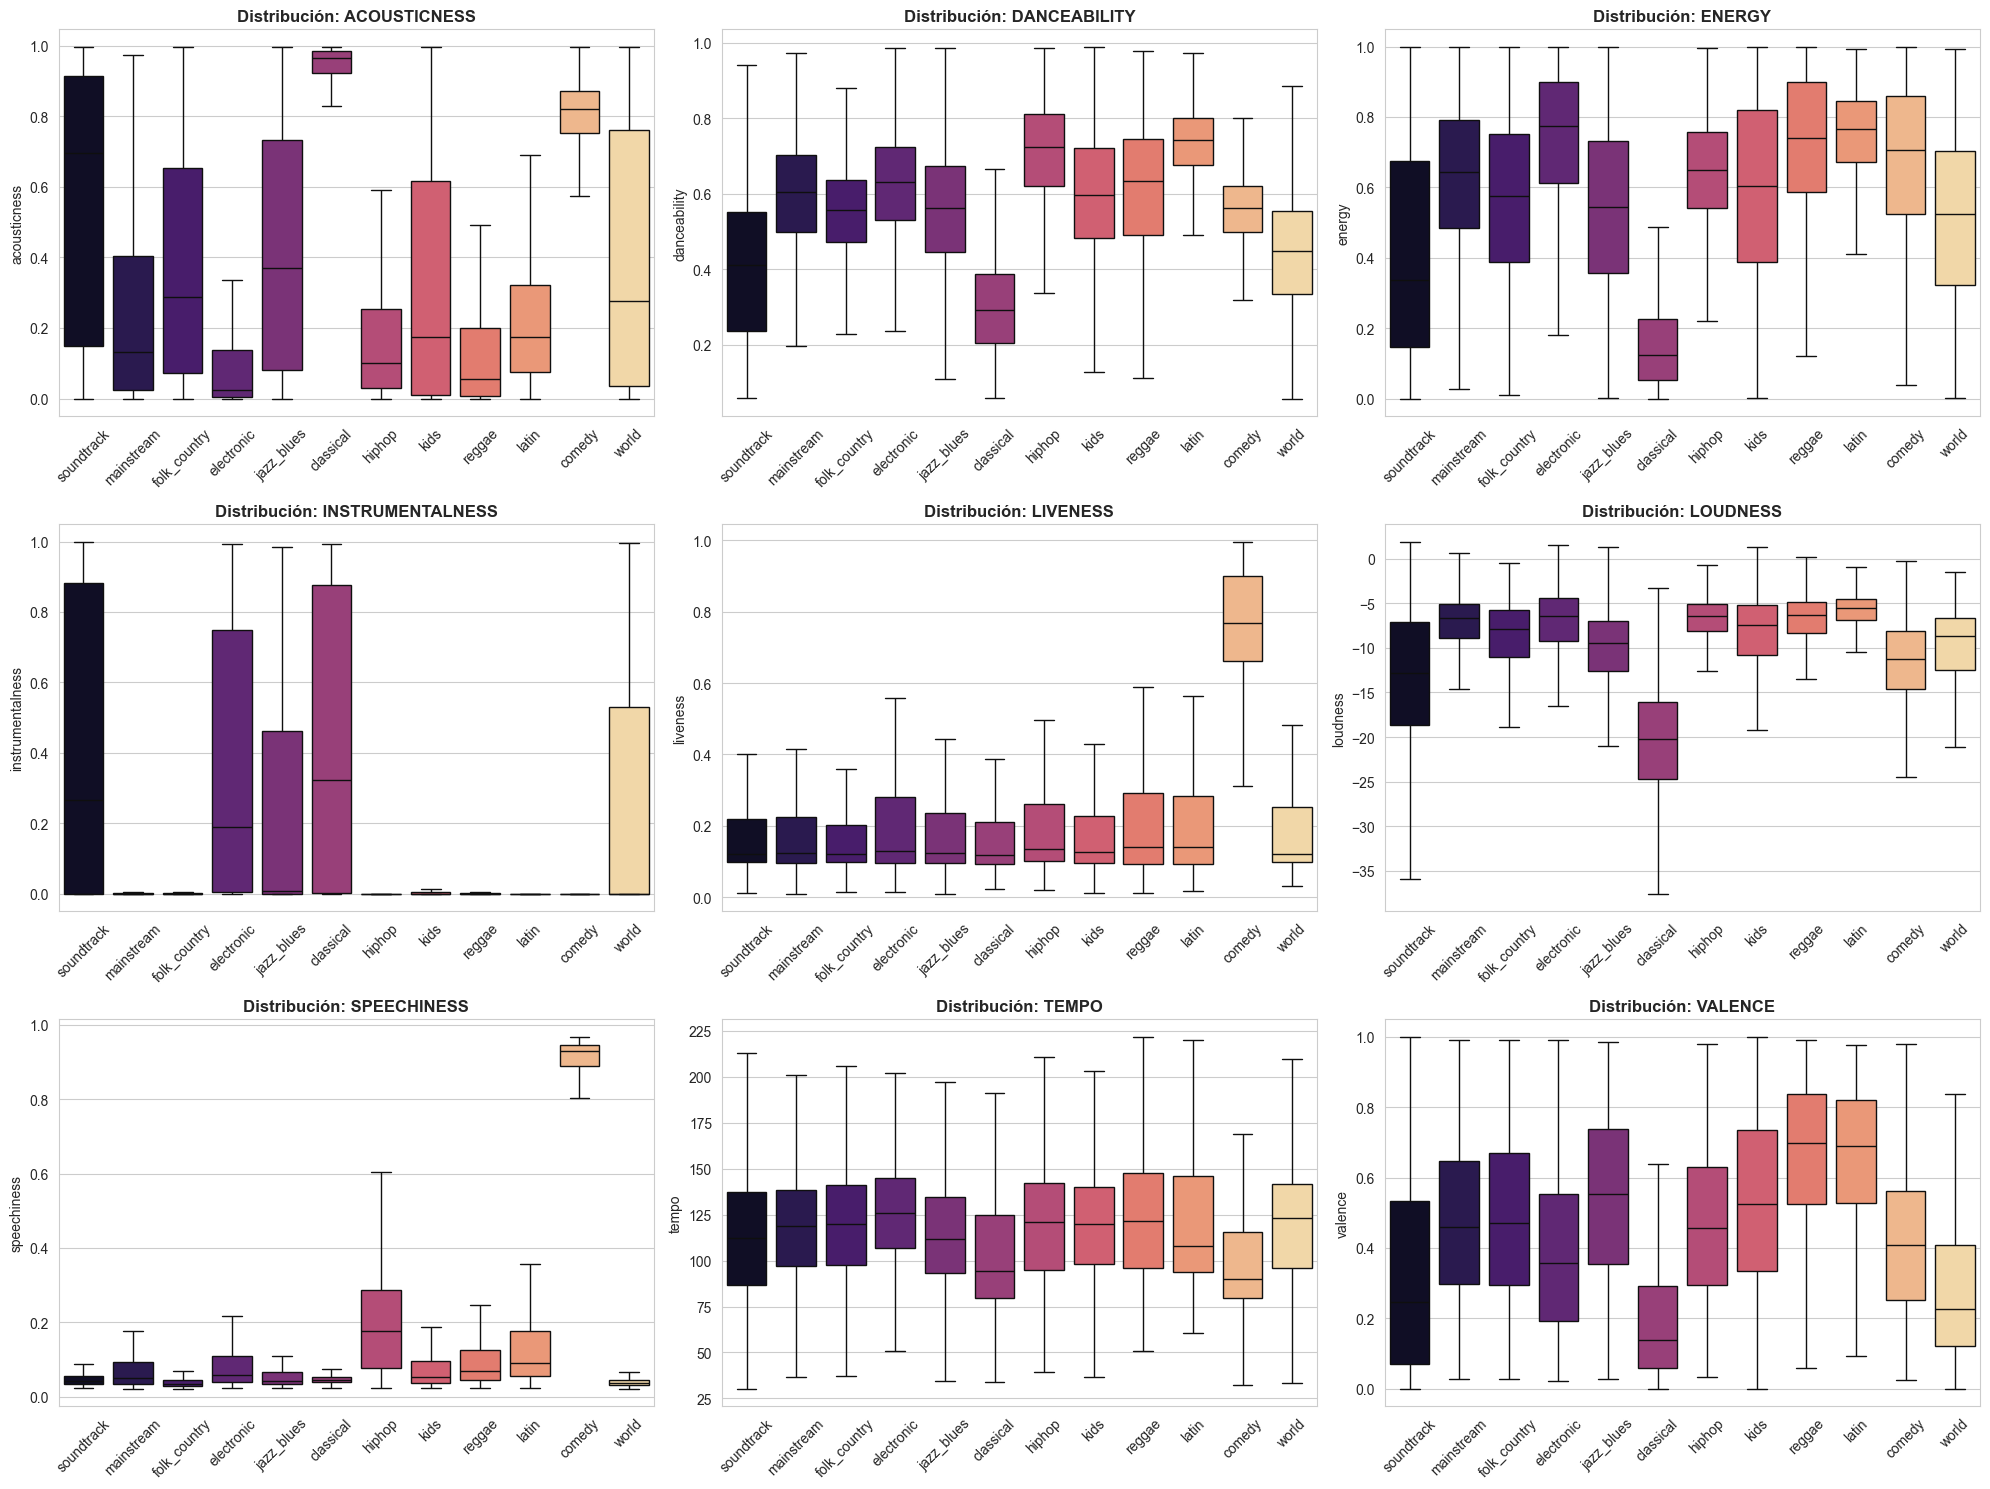

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Matriz de correlación para las variables numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['duration_ms', 'key', 'mode', 'time_signature', 'popularity']:
    if col in cols_numericas: cols_numericas.remove(col)
perfil_medios = df.groupby('genre_grouped')[cols_numericas].mean()
perfil_norm = (perfil_medios - perfil_medios.min()) / (perfil_medios.max() - perfil_medios.min())

plt.figure(figsize=(16, 10))
sns.heatmap(perfil_norm, 
            annot=perfil_medios,
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=.5,
            cbar_kws={'label': 'Intensidad relativa (Min-Max por columna)'})

plt.title('Perfil Acústico Global por Macro-Género (Medias Reales con Escala Normalizada)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Macro-Género', fontsize=12)
plt.xlabel('Características de Audio', fontsize=12)
plt.show()

# Tablas de desviaciones estándar por macro-género




# Boxplots com respecto a 'genre_grouped_4' para cada variable numérica

n_cols = 3
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='genre_grouped', y=col, data=df, ax=axes[i], palette='magma', showfliers=False)
    axes[i].set_title(f'Distribución: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

| Macro-Género | Características más fuertes | Valor | Interpretación                      |
| ------------ | --------------------------- | ----- | ----------------------------------- |
| Classical    | acousticness ↑              | 0.90  | Alta relación con sonido acústico   |
| Classical    | instrumentalness ↑          | 0.43  | Fuerte presencia instrumental       |
| Comedy       | speechiness ↑               | 0.85  | Muy alta relación con voz hablada   |
| Comedy       | liveness ↑                  | 0.72  | Contenido tipo show en vivo         |
| Electronic   | energy ↑                    | 0.74  | Alta intensidad                     |
| Electronic   | danceability ↑              | 0.62  | Fuerte relación con música bailable |
| Hip hop      | danceability ↑              | 0.71  | Muy bailable                        |
| Hip hop      | speechiness ↑               | 0.20  | Presencia de rap (hablado)          |
| Latin        | energy ↑                    | 0.75  | Muy energético                      |
| Latin        | danceability ↑              | 0.73  | Altamente bailable                  |
| Reggae       | valence ↑                   | 0.67  | Música positiva/relajada            |
| Reggae       | energy ↑                    | 0.73  | Energía moderadamente alta          |
| Jazz/Blues   | valence ↑                   | 0.54  | Emoción moderada                    |
| Jazz/Blues   | acousticness ↑              | 0.42  | Tendencia acústica                  |
| Soundtrack   | instrumentalness ↑          | 0.42  | Música mayormente instrumental      |
| Soundtrack   | acousticness ↑              | 0.57  | Sonido más natural                  |


| Relación                 | “Correlación” aproximada |
| ------------------------ | ------------------------ |
| acousticness ↔️ classical | 90%                      |
| speechiness ↔️ comedy     | 85%                      |
| energy ↔️ latin           | 75%                      |
| danceability ↔️ latin     | 73%                      |
| energy ↔️ electronic      | 74%                      |
| valence ↔️ reggae         | 67%                      |
| danceability ↔️ hip hop   | 71%                      |

A partir de la tabla de correlacion se identificaron que algunos Grupos de genero tienen una correlacion muy fuerte entre si, tal como "classical" y "acousticness " que alcanzaron una correlacion de hasta el 90% o "comedy " y "speechiness", esos patrones de correlacion  indican una alta linealidad que significa que son muy buenas variables que pueden ayudar en la prediccion de los modelos
(Tablas realizadas utilizando ChatGPT)

Al observar los boxsplot de cada caracteristica de audio con los grupos de generos se puede identificar que algunas variables tales como "ACOUSTICNESS" y "SPECHNESS" muestran una distribuicions muy separada por genero teniendo por lo tanto un alto poder discriminatorio, diferente a variables como "liveness", "tempo" que se ven muy uninformes

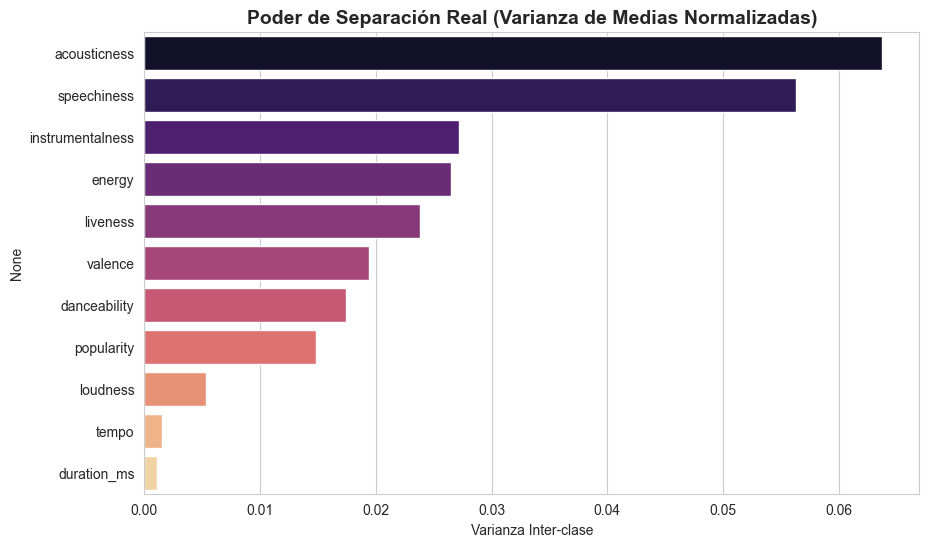

acousticness        0.063771
speechiness         0.056320
instrumentalness    0.027197
energy              0.026509
liveness            0.023860
valence             0.019384
danceability        0.017450
popularity          0.014871
loudness            0.005295
tempo               0.001520
duration_ms         0.001068
dtype: float64


In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. Seleccionamos solo las cuantitativas
cols_cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Normalizamos temporalmente para que todas valgan lo mismo (escala 0-1)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_cuantitativas]), columns=cols_cuantitativas)
df_scaled['genre_grouped'] = df['genre_grouped'].values

# 3. Calculamos la Varianza de las Medias
# Esto mide qué tanto se alejan los promedios de los grupos entre sí
ranking_separacion = df_scaled.groupby('genre_grouped').mean().var().sort_values(ascending=False)

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_separacion.values, y=ranking_separacion.index, palette='magma')
plt.title('Poder de Separación Real (Varianza de Medias Normalizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Varianza Inter-clase')
plt.show()

print(ranking_separacion)

Al analizar la varianza  y las medias de cada caracteristica de auidio da como resultado la anterior grafica que por tanto muestra que caracteristicas de audio tienen un alto poder discriminatorio de genero y de igual manera que en el anterior grafico, pero ahora de manera mas clara, las variables que mayor poder discriminatorio poseen son "ACOUSTICNESS" y "SPECHNESS", por el contrario "tempo", "loudness" y"duration_ms" muestran un bajo poder discriminatorio entre los grupos de genero por tanto al momento de usar el modelo se prioriza usar esas variables con mayor poder discriminatorio

Conclusión del EDA – Agrupación Raíz
En este notebook se realizo un análisis exploratorio a los nuevos macro géneros luego de su agrupación y la limpieza de datos, a continuacion se resumen los allazgos de este notebook

* Se observo un fuerte desbalance entre el macro genero "mainstream" y los otros macro-generos por lo tanto se deben aplicar metodos de desbalanceo antes de que los datos ingresen al modelo predictor
* A partir de las graficas y tablas del notebook se identificaron algunas variables con una fuerte correlación lineal tal como "Classical" con "acousticness " con una correlacion del 90%
* Se identificaron dos variables con un fuerte poder discriminatorio de "caracteristicas de audio" que son "SPECHNESS" y "ACOUSTICNESS", estas dos variables tienen un fuerte poder discriminatorio muy util a la hora de poder distinguir entre los macro generos
* En base a los hallazgos encontrados en este notebook se debe realizar un balanceo antes de ingresar los datos a un modelo y luego de esto se priorizara el recall como metrica de exito